<a href="https://colab.research.google.com/github/tomsBifx25/Mus-Glioblastoma-snRNAseq/blob/main/notebooks/Check01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Comparative Single-Nucleus Transcriptomics of Glioblastoma Across the Lifespan**
****
*Thomas Walsh | March 18, 2026*

**Hood College**
*   BIFX 546 — Machine Learning for Bioinformatics, Spring 2026
*   Instructor: Dr. Sarangan (Ravi) Ravichandran
****
**Dataset**

* Name: longevity-db/mouse-glioblastoma-snRNAseq

* Source: https://huggingface.co/datasets/longevity-db/mouse-glioblastoma-snRNAseq | CELLxGENE | GEO: GSE186252
****
**Project Goals**

How does the age-dependent Tumor microenvironment diverge in glioblastoma contexts between young and aged mice?

Aging is the primary risk factor for glioblastoma (GBM) and significantly correlates with poorer prognosis. While much research focuses on the tumor's genetic mutations, the age-dependent microenvironment remains under-explored. This dataset is unique because it provides high-resolution, single-nucleus RNA sequencing (snRNA-seq) across "young" and "aged" cohorts, allowing for a granular look at how the aging brain environment modulates cancer progression and immune evasion.

---
# **Loading the Data**
Loading the dataset from Hugging Face using the `datasets` library.
First, it may be necessary to install `datasets` library in colab.

In [1]:
pip install datasets

Although optional, it's recommended to setup a Hugging Face Token for colab to allow for more efficent loading times.

Accessing the Hugging face token key from colab after inital setup:

In [2]:
from google.colab import userdata
HF_TOKEN = userdata.get('HF_TOKEN')

Now, loading the dataset using `load_dataset` and inspect its structure. The dataset ID from Hugging Face is `longevity-db/mouse-glioblastoma-snRNAseq`.

**Recommended loading method from the dataset's README on Hugging Face.**

I used a streamed verison in order to subset the data to make it more managable for colab.

UPDATE - streamline loading w/polaris and only use what you need

In [3]:
!pip install polars pyarrow matplotlib seaborn scipy statsmodels

In [1]:
# THIS WORKED
import polars as pl

# Define the URL for the expression.parquet file on Hugging Face
Exp_pq_url = "https://huggingface.co/datasets/longevity-db/mouse-glioblastoma-snRNAseq/resolve/main/expression.parquet"

# Lazy scan from the Hugging Face URL
expr = pl.scan_parquet(Exp_pq_url)

# Peek schema without loading data
print(expr.schema)

/tmp/ipykernel_54886/2990211394.py:11: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  print(expr.schema)


Schema({'ENSMUSG00000051951': Float32, 'ENSMUSG00000089699': Float32, 'ENSMUSG00000102331': Float32, 'ENSMUSG00000025900': Float32, 'ENSMUSG00000025902': Float32, 'ENSMUSG00000104238': Float32, 'ENSMUSG00000104328': Float32, 'ENSMUSG00000033845': Float32, 'ENSMUSG00000025903': Float32, 'ENSMUSG00000033813': Float32, 'ENSMUSG00000002459': Float32, 'ENSMUSG00000085623': Float32, 'ENSMUSG00000033793': Float32, 'ENSMUSG00000025905': Float32, 'ENSMUSG00000025907': Float32, 'ENSMUSG00000090031': Float32, 'ENSMUSG00000087247': Float32, 'ENSMUSG00000033740': Float32, 'ENSMUSG00000051285': Float32, 'ENSMUSG00000097797': Float32, 'ENSMUSG00000025909': Float32, 'ENSMUSG00000061024': Float32, 'ENSMUSG00000025911': Float32, 'ENSMUSG00000079671': Float32, 'ENSMUSG00000067879': Float32, 'ENSMUSG00000099827': Float32, 'ENSMUSG00000025912': Float32, 'ENSMUSG00000045210': Float32, 'ENSMUSG00000097893': Float32, 'ENSMUSG00000025915': Float32, 'ENSMUSG00000046101': Float32, 'ENSMUSG00000098234': Float32, 

### Re-checking metadata to ensure aged data is loaded

In [40]:
# Define the URL for the cell_metadata.parquet file on Hugging Face
meta_parq = "https://huggingface.co/datasets/longevity-db/mouse-glioblastoma-snRNAseq/resolve/main/cell_metadata.parquet"

meta = pl.read_parquet(meta_parq)
print("Cell Meta Data: First five rows")
display(meta.head())

print("\nUnique values in development_stage after initial load:")
display(meta.select(pl.col("development_stage").unique()))

Cell Meta Data: First five rows


nCount_RNA,nFeature_RNA,sub_celltype,assay_ontology_term_id,organism_ontology_term_id,development_stage_ontology_term_id,disease_ontology_term_id,is_primary_data,self_reported_ethnicity_ontology_term_id,sex_ontology_term_id,suspension_type,tissue_type,tissue_ontology_term_id,sample_id,groupid,donor_id,author_celltype,cell_type_ontology_term_id,cell_type,assay,disease,organism,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid,n_genes,cell_id
f64,i32,str,str,str,str,str,bool,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,str
1113.0,591,"""Astrocyte""","""EFO:0009922""","""NCBITaxon:10090""","""MmusDv:0000062""","""MONDO:0018177""",true,"""na""","""PATO:0000383""","""cell""","""tissue""","""UBERON:0000955""","""3920-19""","""Nf1""","""Nf1.mGBM.1""","""Astrocyte""","""CL:0000127""","""astrocyte""","""10x 3' v3""","""glioblastoma""","""Mus musculus""","""female""","""brain""","""na""","""2-month-old stage""","""UrkBeMgX@4""",588,"""3920-19_AAACCCACAAACACCT-1"""
1417.0,755,"""Tumor""","""EFO:0009922""","""NCBITaxon:10090""","""MmusDv:0000062""","""MONDO:0018177""",true,"""na""","""PATO:0000383""","""cell""","""tissue""","""UBERON:0000955""","""3920-19""","""Nf1""","""Nf1.mGBM.1""","""Tumor""","""CL:0001063""","""neoplastic cell""","""10x 3' v3""","""glioblastoma""","""Mus musculus""","""female""","""brain""","""na""","""2-month-old stage""","""@x{bDyo8WK""",754,"""3920-19_AAACCCAGTCCAACGC-1"""
8532.0,3448,"""Tumor""","""EFO:0009922""","""NCBITaxon:10090""","""MmusDv:0000062""","""MONDO:0018177""",true,"""na""","""PATO:0000383""","""cell""","""tissue""","""UBERON:0000955""","""3920-19""","""Nf1""","""Nf1.mGBM.1""","""Tumor""","""CL:0001063""","""neoplastic cell""","""10x 3' v3""","""glioblastoma""","""Mus musculus""","""female""","""brain""","""na""","""2-month-old stage""","""za~S?77j{3""",3441,"""3920-19_AAACCCAGTGCGTTTA-1"""
8987.0,3554,"""Tumor""","""EFO:0009922""","""NCBITaxon:10090""","""MmusDv:0000062""","""MONDO:0018177""",true,"""na""","""PATO:0000383""","""cell""","""tissue""","""UBERON:0000955""","""3920-19""","""Nf1""","""Nf1.mGBM.1""","""Tumor""","""CL:0001063""","""neoplastic cell""","""10x 3' v3""","""glioblastoma""","""Mus musculus""","""female""","""brain""","""na""","""2-month-old stage""","""jm43>$?2c0""",3546,"""3920-19_AAACCCAGTGGATACG-1"""
1669.0,951,"""Tumor""","""EFO:0009922""","""NCBITaxon:10090""","""MmusDv:0000062""","""MONDO:0018177""",true,"""na""","""PATO:0000383""","""cell""","""tissue""","""UBERON:0000955""","""3920-19""","""Nf1""","""Nf1.mGBM.1""","""Tumor""","""CL:0001063""","""neoplastic cell""","""10x 3' v3""","""glioblastoma""","""Mus musculus""","""female""","""brain""","""na""","""2-month-old stage""","""Y^c3RkVgoa""",946,"""3920-19_AAACCCATCCTATTGT-1"""



Unique values in development_stage after initial load:


development_stage
str
"""2-month-old stage"""


### Exploring the full dataset for 'aged' metadata

Given that loading `cell_metadata.parquet` directly only yielded '2-month-old stage', we will try loading the full dataset using the `datasets` library to see if a more complete set of `development_stage` values, including 'aged' ones, is available through this method. This cell will load the dataset and print its features to understand its structure before attempting to extract specific metadata.

In [ ]:
from datasets import load_dataset

dataset_name = "longevity-db/mouse-glioblastoma-snRNAseq"

print(f"Loading the full dataset object from Hugging Face: {dataset_name} to inspect its features...")

# Load the full dataset (not streaming initially) to inspect its structure
try:
    full_dataset = load_dataset(dataset_name, split='train')
    print("Successfully loaded the full dataset object.")

    print("\nDataset Features:")
    print(full_dataset.features)

    # Attempt to sample a small portion of the cell_metadata feature
    # to check unique development stages if cell_metadata is directly accessible as a column
    if 'development_stage' in full_dataset.features:
        print("\nSampling development_stage from the full dataset to check for 'aged' data:")
        # Take a small sample to avoid memory issues with .to_pandas() on the entire dataset
        sample_stages = full_dataset.select(range(min(1000, len(full_dataset))))['development_stage']
        unique_sample_stages = list(set(sample_stages))
        print(f"Unique development stages in a sample: {unique_sample_stages}")

    else:
        print("development_stage column not directly found as a top-level feature.")
        print("Further investigation into nested features (e.g., 'cell_metadata' if it exists) may be needed.")

except Exception as e:
    print(f"Error loading dataset for feature inspection: {e}")
    print("It might be too large to load even the object metadata or there's a network issue.")

Loading the full dataset object from Hugging Face: longevity-db/mouse-glioblastoma-snRNAseq to inspect its features...


Generating train split:   0%|          | 0/430956 [00:00<?, ? examples/s]

In [38]:
# Define the URL for the cell_metadata.parquet file on Hugging Face
meta_parq = "https://huggingface.co/datasets/longevity-db/mouse-glioblastoma-snRNAseq/resolve/main/cell_metadata.parquet"

meta = pl.read_parquet(meta_parq)
print("Cell Meta Data: First five rows")
display(meta.head())

print("\nUnique values in development_stage after initial load:")
display(meta.select(pl.col("development_stage").unique()))

Cell Meta Data: First five rows


nCount_RNA,nFeature_RNA,sub_celltype,assay_ontology_term_id,organism_ontology_term_id,development_stage_ontology_term_id,disease_ontology_term_id,is_primary_data,self_reported_ethnicity_ontology_term_id,sex_ontology_term_id,suspension_type,tissue_type,tissue_ontology_term_id,sample_id,groupid,donor_id,author_celltype,cell_type_ontology_term_id,cell_type,assay,disease,organism,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid,n_genes,cell_id
f64,i32,str,str,str,str,str,bool,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,str
1113.0,591,"""Astrocyte""","""EFO:0009922""","""NCBITaxon:10090""","""MmusDv:0000062""","""MONDO:0018177""",true,"""na""","""PATO:0000383""","""cell""","""tissue""","""UBERON:0000955""","""3920-19""","""Nf1""","""Nf1.mGBM.1""","""Astrocyte""","""CL:0000127""","""astrocyte""","""10x 3' v3""","""glioblastoma""","""Mus musculus""","""female""","""brain""","""na""","""2-month-old stage""","""UrkBeMgX@4""",588,"""3920-19_AAACCCACAAACACCT-1"""
1417.0,755,"""Tumor""","""EFO:0009922""","""NCBITaxon:10090""","""MmusDv:0000062""","""MONDO:0018177""",true,"""na""","""PATO:0000383""","""cell""","""tissue""","""UBERON:0000955""","""3920-19""","""Nf1""","""Nf1.mGBM.1""","""Tumor""","""CL:0001063""","""neoplastic cell""","""10x 3' v3""","""glioblastoma""","""Mus musculus""","""female""","""brain""","""na""","""2-month-old stage""","""@x{bDyo8WK""",754,"""3920-19_AAACCCAGTCCAACGC-1"""
8532.0,3448,"""Tumor""","""EFO:0009922""","""NCBITaxon:10090""","""MmusDv:0000062""","""MONDO:0018177""",true,"""na""","""PATO:0000383""","""cell""","""tissue""","""UBERON:0000955""","""3920-19""","""Nf1""","""Nf1.mGBM.1""","""Tumor""","""CL:0001063""","""neoplastic cell""","""10x 3' v3""","""glioblastoma""","""Mus musculus""","""female""","""brain""","""na""","""2-month-old stage""","""za~S?77j{3""",3441,"""3920-19_AAACCCAGTGCGTTTA-1"""
8987.0,3554,"""Tumor""","""EFO:0009922""","""NCBITaxon:10090""","""MmusDv:0000062""","""MONDO:0018177""",true,"""na""","""PATO:0000383""","""cell""","""tissue""","""UBERON:0000955""","""3920-19""","""Nf1""","""Nf1.mGBM.1""","""Tumor""","""CL:0001063""","""neoplastic cell""","""10x 3' v3""","""glioblastoma""","""Mus musculus""","""female""","""brain""","""na""","""2-month-old stage""","""jm43>$?2c0""",3546,"""3920-19_AAACCCAGTGGATACG-1"""
1669.0,951,"""Tumor""","""EFO:0009922""","""NCBITaxon:10090""","""MmusDv:0000062""","""MONDO:0018177""",true,"""na""","""PATO:0000383""","""cell""","""tissue""","""UBERON:0000955""","""3920-19""","""Nf1""","""Nf1.mGBM.1""","""Tumor""","""CL:0001063""","""neoplastic cell""","""10x 3' v3""","""glioblastoma""","""Mus musculus""","""female""","""brain""","""na""","""2-month-old stage""","""Y^c3RkVgoa""",946,"""3920-19_AAACCCATCCTATTGT-1"""



Unique values in development_stage after initial load:


development_stage
str
"""2-month-old stage"""


In [1]:
# This cell will now load `meta` directly from `cell_metadata.parquet`.
# Please note that previous attempts to load `cell_metadata.parquet` directly
# resulted in only '2-month-old stage' being present in the 'development_stage' column,
# potentially leading to a lack of 'aged' data for comparison.

import polars as pl

dataset_name = "longevity-db/mouse-glioblastoma-snRNAseq"
meta_parq = f"https://huggingface.co/datasets/{dataset_name}/resolve/main/cell_metadata.parquet"

print(f"Loading cell metadata from: {meta_parq}. This will load only the metadata parquet file.")

meta = pl.read_parquet(meta_parq)

print("Successfully loaded cell metadata.")
print("Cell Meta Data: First five rows")
display(meta.head())

print("\nUnique values in development_stage after loading directly from parquet:")
display(meta.select(pl.col("development_stage").unique()))

# The expression.parquet is handled in other cells.

Loading cell metadata from: https://huggingface.co/datasets/longevity-db/mouse-glioblastoma-snRNAseq/resolve/main/cell_metadata.parquet. This will load only the metadata parquet file.
Successfully loaded cell metadata.
Cell Meta Data: First five rows


nCount_RNA,nFeature_RNA,sub_celltype,assay_ontology_term_id,organism_ontology_term_id,development_stage_ontology_term_id,disease_ontology_term_id,is_primary_data,self_reported_ethnicity_ontology_term_id,sex_ontology_term_id,suspension_type,tissue_type,tissue_ontology_term_id,sample_id,groupid,donor_id,author_celltype,cell_type_ontology_term_id,cell_type,assay,disease,organism,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid,n_genes,cell_id
f64,i32,str,str,str,str,str,bool,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,str
1113.0,591,"""Astrocyte""","""EFO:0009922""","""NCBITaxon:10090""","""MmusDv:0000062""","""MONDO:0018177""",true,"""na""","""PATO:0000383""","""cell""","""tissue""","""UBERON:0000955""","""3920-19""","""Nf1""","""Nf1.mGBM.1""","""Astrocyte""","""CL:0000127""","""astrocyte""","""10x 3' v3""","""glioblastoma""","""Mus musculus""","""female""","""brain""","""na""","""2-month-old stage""","""UrkBeMgX@4""",588,"""3920-19_AAACCCACAAACACCT-1"""
1417.0,755,"""Tumor""","""EFO:0009922""","""NCBITaxon:10090""","""MmusDv:0000062""","""MONDO:0018177""",true,"""na""","""PATO:0000383""","""cell""","""tissue""","""UBERON:0000955""","""3920-19""","""Nf1""","""Nf1.mGBM.1""","""Tumor""","""CL:0001063""","""neoplastic cell""","""10x 3' v3""","""glioblastoma""","""Mus musculus""","""female""","""brain""","""na""","""2-month-old stage""","""@x{bDyo8WK""",754,"""3920-19_AAACCCAGTCCAACGC-1"""
8532.0,3448,"""Tumor""","""EFO:0009922""","""NCBITaxon:10090""","""MmusDv:0000062""","""MONDO:0018177""",true,"""na""","""PATO:0000383""","""cell""","""tissue""","""UBERON:0000955""","""3920-19""","""Nf1""","""Nf1.mGBM.1""","""Tumor""","""CL:0001063""","""neoplastic cell""","""10x 3' v3""","""glioblastoma""","""Mus musculus""","""female""","""brain""","""na""","""2-month-old stage""","""za~S?77j{3""",3441,"""3920-19_AAACCCAGTGCGTTTA-1"""
8987.0,3554,"""Tumor""","""EFO:0009922""","""NCBITaxon:10090""","""MmusDv:0000062""","""MONDO:0018177""",true,"""na""","""PATO:0000383""","""cell""","""tissue""","""UBERON:0000955""","""3920-19""","""Nf1""","""Nf1.mGBM.1""","""Tumor""","""CL:0001063""","""neoplastic cell""","""10x 3' v3""","""glioblastoma""","""Mus musculus""","""female""","""brain""","""na""","""2-month-old stage""","""jm43>$?2c0""",3546,"""3920-19_AAACCCAGTGGATACG-1"""
1669.0,951,"""Tumor""","""EFO:0009922""","""NCBITaxon:10090""","""MmusDv:0000062""","""MONDO:0018177""",true,"""na""","""PATO:0000383""","""cell""","""tissue""","""UBERON:0000955""","""3920-19""","""Nf1""","""Nf1.mGBM.1""","""Tumor""","""CL:0001063""","""neoplastic cell""","""10x 3' v3""","""glioblastoma""","""Mus musculus""","""female""","""brain""","""na""","""2-month-old stage""","""Y^c3RkVgoa""",946,"""3920-19_AAACCCATCCTATTGT-1"""



Unique values in development_stage after loading directly from parquet:


development_stage
str
"""2-month-old stage"""


Use gene names to target ensembl ID's

In [28]:
# Gene names with ensembl ids
gene_to_ensembl = {
    "Il1b": "ENSMUSG00000027398",
    "Tnf": "ENSMUSG00000024401",
    "Cxcl10": "ENSMUSG00000034855",
    "Pdcd1": "ENSMUSG00000026285",
    "Lag3": "ENSMUSG00000030124",
    "Ctla4": "ENSMUSG00000026011",
    "Cd68": "ENSMUSG00000018774",
    "Itgam": "ENSMUSG00000030786"
}

# The 'mapped' dictionary is now simply the 'gene_to_ensembl' dict
print("Genes of Interest:", gene_to_ensembl)


Genes of Interest: {'Il1b': 'ENSMUSG00000027398', 'Tnf': 'ENSMUSG00000024401', 'Cxcl10': 'ENSMUSG00000034855', 'Pdcd1': 'ENSMUSG00000026285', 'Lag3': 'ENSMUSG00000030124', 'Ctla4': 'ENSMUSG00000026011', 'Cd68': 'ENSMUSG00000018774', 'Itgam': 'ENSMUSG00000030786'}


In [29]:
# verify genes and ensembl ids are in data
schema = expr.collect_schema()
available = set(schema.keys())

present = {g: eid for g, eid in gene_to_ensembl.items() if eid in available}
missing = {g: eid for g, eid in gene_to_ensembl.items() if eid not in available}

print("Present:", present)
print("Missing:", missing)

Present: {'Il1b': 'ENSMUSG00000027398', 'Tnf': 'ENSMUSG00000024401', 'Cxcl10': 'ENSMUSG00000034855', 'Pdcd1': 'ENSMUSG00000026285', 'Lag3': 'ENSMUSG00000030124', 'Ctla4': 'ENSMUSG00000026011', 'Cd68': 'ENSMUSG00000018774', 'Itgam': 'ENSMUSG00000030786'}
Missing: {}


load only necessary:

In [32]:
# Prepare metadata
meta_filtered = meta.select([
    "cell_id",
    "development_stage",
    "cell_type",
    "sex",
    "nCount_RNA",
    "nFeature_RNA",
    "n_genes"])

# Define age groups
meta_filtered = meta_filtered.with_columns(
    pl.when(pl.col("development_stage").str.contains("2-month"))
      .then(pl.lit("young"))
      .otherwise(pl.lit("aged"))
      .alias("age_group"))

Sample 5000 young + 5000 aged

In [37]:
# filter meta data
meta_df = meta_filtered

# find and split them into age groups
young_df = meta_df.filter(pl.col("age_group") == "young")
aged_df = meta_df.filter(pl.col("age_group") == "aged")

# sample to get the desired 5k for each group
young_sample = young_df.sample(n=min(5000, len(young_df)), seed=42)

# Check if aged_df is empty before attempting to sample
if len(aged_df) > 0:
    aged_sample = aged_df.sample(n=min(5000, len(aged_df)), seed=42)
else:
    print("Warning: aged_df is empty. No aged samples will be included in meta_sampled.")
    aged_sample = pl.DataFrame(schema=meta_df.schema) # Create an empty DataFrame with the correct schema

# combine them together
meta_sampled = pl.concat([young_sample, aged_sample])

print(f"Sampled {len(young_sample)} young cells and {len(aged_sample)} aged cells.")

# New code to inspect development_stage
print("\nUnique values in development_stage:")
print(meta_df.select(pl.col("development_stage").unique()))

Sampled 5000 young cells and 0 aged cells.

Unique values in development_stage:
shape: (1, 1)
┌───────────────────┐
│ development_stage │
│ ---               │
│ str               │
╞═══════════════════╡
│ 2-month-old stage │
└───────────────────┘


V_422:

In [14]:
columns_to_load = ["cell_id"] + list(present.values())

# Use the URL for expression data defined earlier
expr_subset = pl.scan_parquet(Exp_pq_url).select(columns_to_load)

print("Expression subset loaded successfully with selected columns.")

Expression subset loaded successfully with selected columns.
naive plan: (run LazyFrame.explain(optimized=True) to see the optimized plan)

SELECT [col("cell_id"), col("ENSMUSG00000027398"), col("ENSMUSG00000024401"), col("ENSMUSG00000034855"), col("ENSMUSG00000026285"), col("ENSMUSG00000030124"), col("ENSMUSG00000026011"), col("ENSMUSG00000018774"), col("ENSMUSG00000030786")]
  Parquet SCAN [https://huggingface.co/datasets/longevity-db/mouse-glioblastoma-snRNAseq/resolve/main/expression.parquet]
  PROJECT */25092 COLUMNS
  ESTIMATED ROWS: 94181


In [19]:
# join with meta data and define our age groups
df = expr_subset.join(meta.lazy(), on="cell_id")

df = df.with_columns(pl.when(pl.col("development_stage").str.contains("2-month"))
      .then(pl.lit("young"))
      .otherwise(pl.lit("aged"))
      .alias("age_group"))


In [20]:
# rename the columns for each gene
df = df.rename({v: k for k, v in present.items()})

meaningful summaries

In [23]:
# Gene-level comparison
agg = (df.group_by(["age_group", "cell_type"])
      .agg([pl.col(g).mean().alias(g) for g in present.keys()])
      .collect())

# Comparison Based on panels
gene_panels = {"inflammation": ["Il1b", "Tnf", "Cxcl10"],
               "tcell_exhaustion": ["Pdcd1", "Lag3", "Ctla4"],
               "myeloid": ["Cd68", "Itgam"]}

df = df.with_columns([
    pl.mean_horizontal([pl.col(g) for g in gene_panels["inflammation"]])
      .alias("inflammation_score"),

    pl.mean_horizontal([pl.col(g) for g in gene_panels["tcell_exhaustion"]])
      .alias("tcell_exhaustion_score"),

    pl.mean_horizontal([pl.col(g) for g in gene_panels["myeloid"]])
      .alias("myeloid_score"),])

# Aggregate scores
scores = (df.group_by(["age_group", "cell_type"])
      .agg([pl.col("inflammation_score").mean(),
            pl.col("tcell_exhaustion_score").mean(),
            pl.col("myeloid_score").mean()])
      .collect())

Test plot

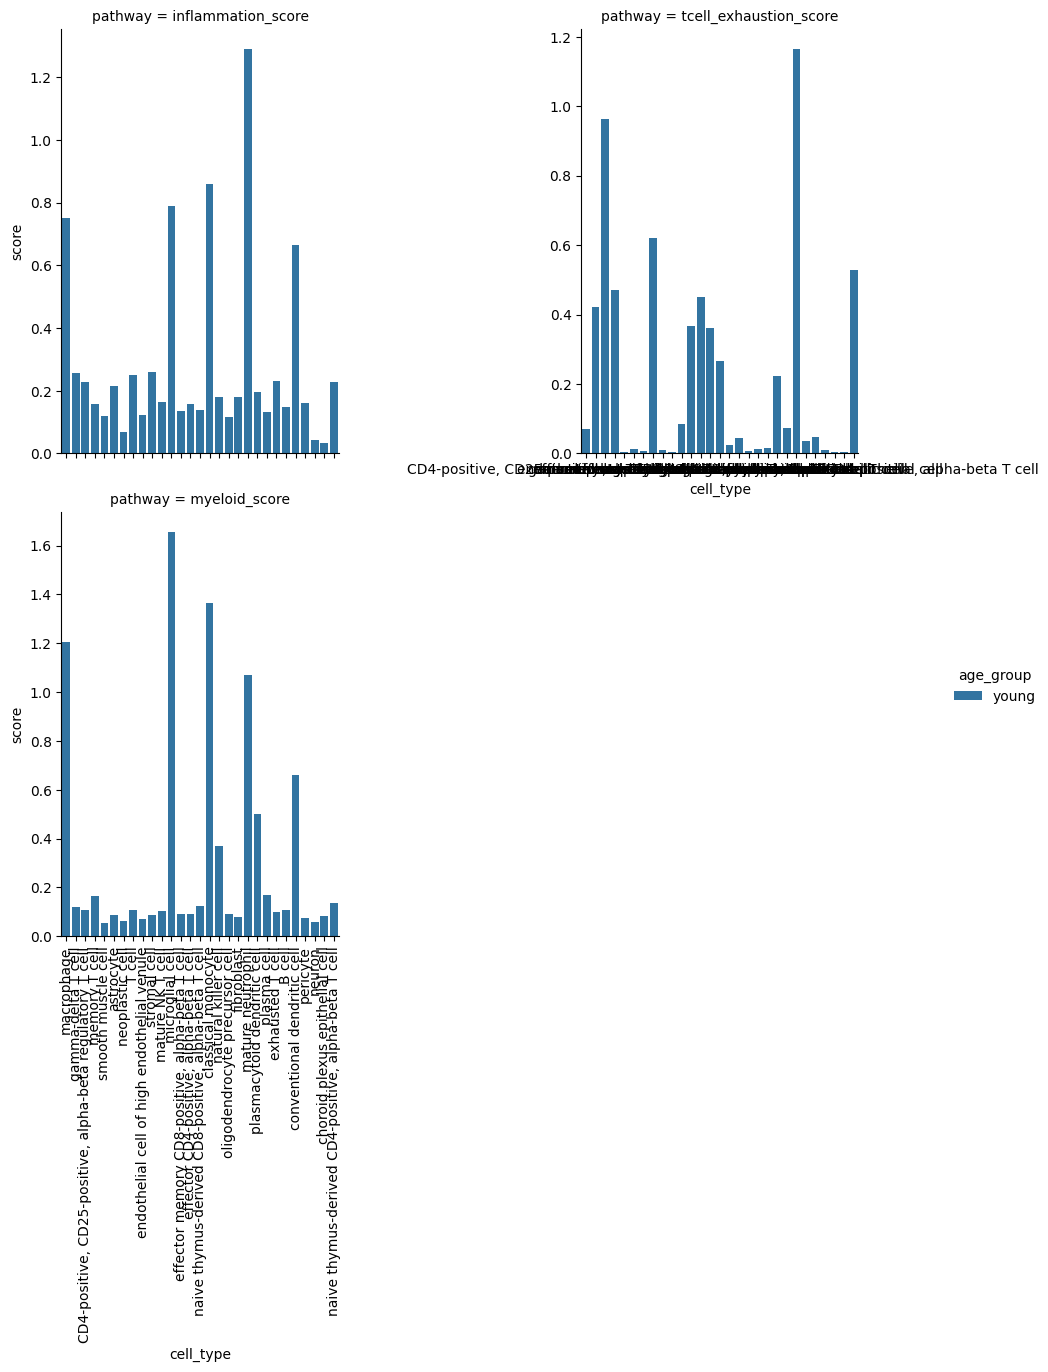

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

pdf = scores.to_pandas().melt(
    id_vars=["age_group", "cell_type"],
    var_name="pathway",
    value_name="score"
)

sns.catplot(
    data=pdf,
    x="cell_type",
    y="score",
    hue="age_group",
    col="pathway",
    kind="bar",
    sharey=False,
    col_wrap=2
)

plt.xticks(rotation=90)
plt.show()

Below is old:

In [ ]:
# May take ~30secs to run
from datasets import load_dataset
import pandas as pd

dataset_name = "longevity-db/mouse-glioblastoma-snRNAseq"

try:
    # Load the dataset in streaming mode
    # This allows processing data without loading the entire dataset into memory
    # which is ideal for getting a 'smaller, more manageable portion'.
    streamed_dataset = load_dataset(dataset_name, streaming=True)

    # With the 'train' split, we'll take the first 10000 examples.
    # Adjust this number as needed.
    sample_size = 10000
    sampled_data = []
    for i, example in enumerate(streamed_dataset['train']):
        if i >= sample_size:
            break
        sampled_data.append(example)

    # Convert the sampled data to a Pandas DataFrame for easier manipulation
    df_sampled = pd.DataFrame(sampled_data)

    print(f"Successfully loaded a sample of {len(df_sampled)} examples.")
    print("\nFirst 5 rows of the sampled data:\n")
    display(df_sampled.head())

except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Please ensure the dataset ID is correct, you have network access, and the HF_TOKEN (if required) is set in Colab secrets.")

Successfully loaded a sample of 10000 examples.

First 5 rows of the sampled data:



,nCount_RNA,nFeature_RNA,sub_celltype,assay_ontology_term_id,organism_ontology_term_id,development_stage_ontology_term_id,disease_ontology_term_id,is_primary_data,self_reported_ethnicity_ontology_term_id,sex_ontology_term_id,...,assay,disease,organism,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid,n_genes,cell_id
0,1113.0,591,Astrocyte,EFO:0009922,NCBITaxon:10090,MmusDv:0000062,MONDO:0018177,True,na,PATO:0000383,...,10x 3' v3,glioblastoma,Mus musculus,female,brain,na,2-month-old stage,UrkBeMgX@4,588,3920-19_AAACCCACAAACACCT-1
1,1417.0,755,Tumor,EFO:0009922,NCBITaxon:10090,MmusDv:0000062,MONDO:0018177,True,na,PATO:0000383,...,10x 3' v3,glioblastoma,Mus musculus,female,brain,na,2-month-old stage,@x{bDyo8WK,754,3920-19_AAACCCAGTCCAACGC-1
2,8532.0,3448,Tumor,EFO:0009922,NCBITaxon:10090,MmusDv:0000062,MONDO:0018177,True,na,PATO:0000383,...,10x 3' v3,glioblastoma,Mus musculus,female,brain,na,2-month-old stage,za~S?77j{3,3441,3920-19_AAACCCAGTGCGTTTA-1
3,8987.0,3554,Tumor,EFO:0009922,NCBITaxon:10090,MmusDv:0000062,MONDO:0018177,True,na,PATO:0000383,...,10x 3' v3,glioblastoma,Mus musculus,female,brain,na,2-month-old stage,jm43>$?2c0,3546,3920-19_AAACCCAGTGGATACG-1
4,1669.0,951,Tumor,EFO:0009922,NCBITaxon:10090,MmusDv:0000062,MONDO:0018177,True,na,PATO:0000383,...,10x 3' v3,glioblastoma,Mus musculus,female,brain,na,2-month-old stage,Y^c3RkVgoa,946,3920-19_AAACCCATCCTATTGT-1


**Making Sense of the data**

The following columns are the most relevant to our research question:
* **nCount_RNA** - the number of reads
* **nFeature_RNA** - the number of genes
* **sub_celltype** - the type of cell sample
* **assay** - technology used to sequence the library
* **disease** - *should all be glioblasmoa*
* **organism** - *should all be mouse*
* **sex** - either female or male
* **tissue** - *should all be brain tissues*
* **development_stage** -  2-month-old (*should have an older subset as well*)

---
# **Initial Cleaning**

From the subset, check for any missing values:

In [ ]:
print("Checking for missing values in df_sampled per column:")

found_missing_values = False
for col in df_sampled.columns:
  null_count = df_sampled[col].isnull().sum()
  if null_count > 0:
    print(f"Column '{col}': {null_count} missing values")
    found_missing_values = True

if not found_missing_values:
  print("No missing values found in df_sampled.")

Checking for missing values in df_sampled per column:
No missing values found in df_sampled.


**Next, check for unique values**

* For each column, if there is only one unique value, remove it and place into a new data frame for single values.

* The single unique values may help us to understand the dataset, so I didn't want to delete them but their removal will help to isolate useful data for analysis

In [ ]:
import pandas as pd

single_values_data = {}
cols_to_drop = []

for col in df_sampled.columns:
    unique_vals = df_sampled[col].unique()
    if len(unique_vals) > 1:
        print(f"Column '{col}': There's more than one unique value.")
    else:
        single_values_data[col] = unique_vals[0] # Store the single unique value
        cols_to_drop.append(col) # Mark column for removal
        print(f"Column '{col}': Unique value is '{unique_vals[0]}'")

# Create a new DataFrame for columns with single unique values
df_single_unique_values = pd.DataFrame.from_dict(single_values_data, orient='index', columns=['Unique Value'])
print("\nDataFrame with single unique values:")
display(df_single_unique_values)

# Remove these columns from df_sampled
df_sampled = df_sampled.drop(columns=cols_to_drop)
print("\nOriginal df_sampled after removing columns with single unique values:")
display(df_sampled.head())

Column 'nCount_RNA': There's more than one unique value.
Column 'nFeature_RNA': There's more than one unique value.
Column 'sub_celltype': There's more than one unique value.
Column 'assay_ontology_term_id': Unique value is 'EFO:0009922'
Column 'organism_ontology_term_id': Unique value is 'NCBITaxon:10090'
Column 'development_stage_ontology_term_id': Unique value is 'MmusDv:0000062'
Column 'disease_ontology_term_id': Unique value is 'MONDO:0018177'
Column 'is_primary_data': Unique value is 'True'
Column 'self_reported_ethnicity_ontology_term_id': Unique value is 'na'
Column 'sex_ontology_term_id': There's more than one unique value.
Column 'suspension_type': Unique value is 'cell'
Column 'tissue_type': Unique value is 'tissue'
Column 'tissue_ontology_term_id': Unique value is 'UBERON:0000955'
Column 'sample_id': There's more than one unique value.
Column 'groupid': Unique value is 'Nf1'
Column 'donor_id': There's more than one unique value.
Column 'author_celltype': There's more than o

,Unique Value
assay_ontology_term_id,EFO:0009922
organism_ontology_term_id,NCBITaxon:10090
development_stage_ontology_term_id,MmusDv:0000062
disease_ontology_term_id,MONDO:0018177
is_primary_data,True
self_reported_ethnicity_ontology_term_id,na
suspension_type,cell
tissue_type,tissue
tissue_ontology_term_id,UBERON:0000955
groupid,Nf1



Original df_sampled after removing columns with single unique values:


,nCount_RNA,nFeature_RNA,sub_celltype,sex_ontology_term_id,sample_id,donor_id,author_celltype,cell_type_ontology_term_id,cell_type,sex,observation_joinid,n_genes,cell_id
0,1113.0,591,Astrocyte,PATO:0000383,3920-19,Nf1.mGBM.1,Astrocyte,CL:0000127,astrocyte,female,UrkBeMgX@4,588,3920-19_AAACCCACAAACACCT-1
1,1417.0,755,Tumor,PATO:0000383,3920-19,Nf1.mGBM.1,Tumor,CL:0001063,neoplastic cell,female,@x{bDyo8WK,754,3920-19_AAACCCAGTCCAACGC-1
2,8532.0,3448,Tumor,PATO:0000383,3920-19,Nf1.mGBM.1,Tumor,CL:0001063,neoplastic cell,female,za~S?77j{3,3441,3920-19_AAACCCAGTGCGTTTA-1
3,8987.0,3554,Tumor,PATO:0000383,3920-19,Nf1.mGBM.1,Tumor,CL:0001063,neoplastic cell,female,jm43>$?2c0,3546,3920-19_AAACCCAGTGGATACG-1
4,1669.0,951,Tumor,PATO:0000383,3920-19,Nf1.mGBM.1,Tumor,CL:0001063,neoplastic cell,female,Y^c3RkVgoa,946,3920-19_AAACCCATCCTATTGT-1


---
# **Visualizations**
**Scatter plots**

A basic scatter plot for Count Reads and Genes:

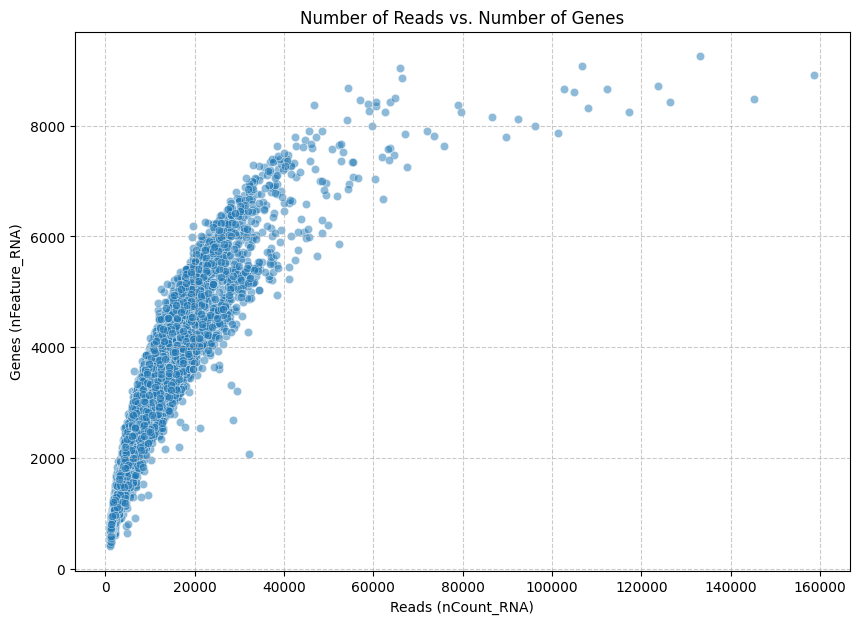

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generate basic scatter plot
plt.figure(figsize=(10, 7))
sns.scatterplot(x='nCount_RNA', y='nFeature_RNA', data=df_sampled, alpha=0.5)

# Plot labels and grid area
plt.title('Number of Reads vs. Number of Genes')
plt.xlabel('Reads (nCount_RNA)')
plt.ylabel('Genes (nFeature_RNA)')
plt.grid(True, linestyle='--', alpha=0.67)

# Display the plot
plt.show()

This scatter plot shows the relationship between `nCount_RNA` (number of reads) and `nFeature_RNA` (number of genes). Typically, a positive correlation is expected, meaning as the number of reads increases, the number of detected genes also tends to increase.

This helps to observe the general trend between these two metrics.

**Scatter plot by cell types:**

For a deeper understanding about the differences the number od reads and the number of genes, we can color by cell type.

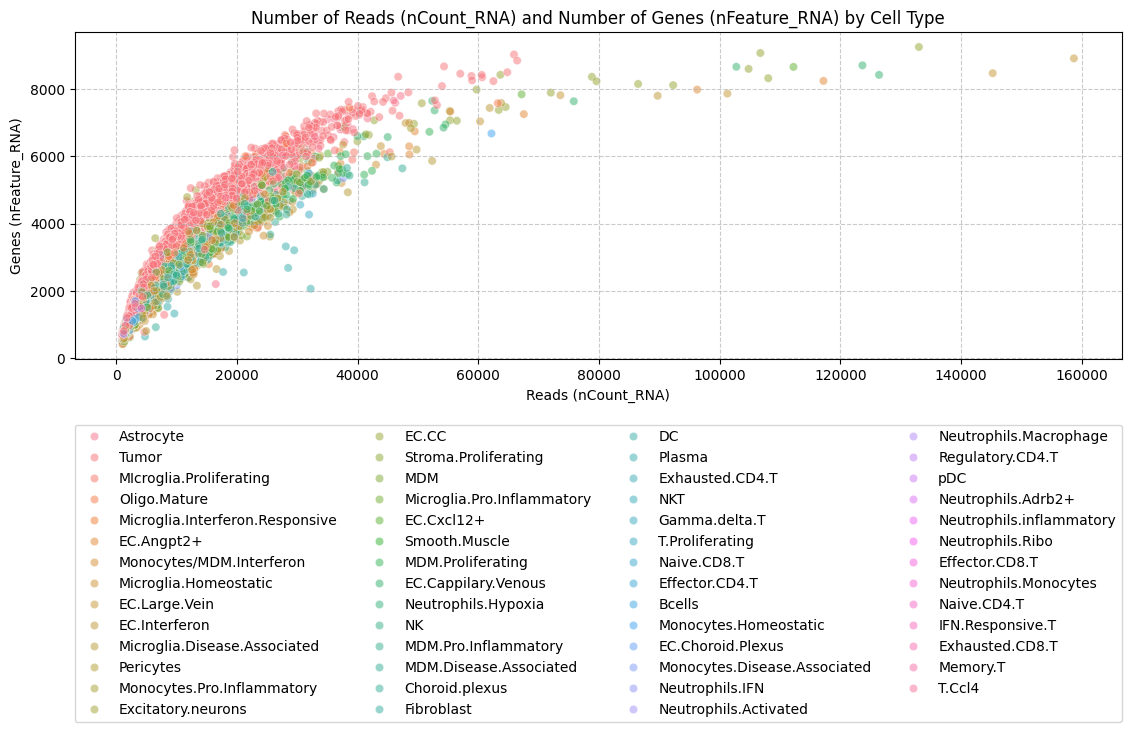

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generate scatter plot
plt.figure(figsize=(12, 8))
sns.scatterplot(x='nCount_RNA', y='nFeature_RNA', hue='sub_celltype', data=df_sampled, alpha=0.5)

# Labels and grid area
plt.title('Number of Reads (nCount_RNA) and Number of Genes (nFeature_RNA) by Cell Type')
plt.xlabel('Reads (nCount_RNA)')
plt.ylabel('Genes (nFeature_RNA)')
plt.grid(True, linestyle='--', alpha=0.67)

# Legend layout, below the plot and horizontally displayed
plt.legend(bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=4, borderaxespad=0.)
plt.tight_layout()

# Display the plot
plt.show()

This scatter plot shows the relationship between `nCount_RNA` and `nFeature_RNA` as before, but colored by cell type.

This helps to visualize which cell types have more expression. As expected, the Astrocyte and "Tumor" cell type (pink) have higher expression levels when compared to other cell types. For this dataset the "tumor" designation is for Glioblastoma.



**Plotting the Number of Reads and Genes by Sex**

There is a relatively even distribution between Female and Male observations.

In [ ]:
print(df_sampled['sex'].value_counts())

sex
female    5787
male      4213
Name: count, dtype: int64


**Scatter plot for Reads and Genes by Sex:**

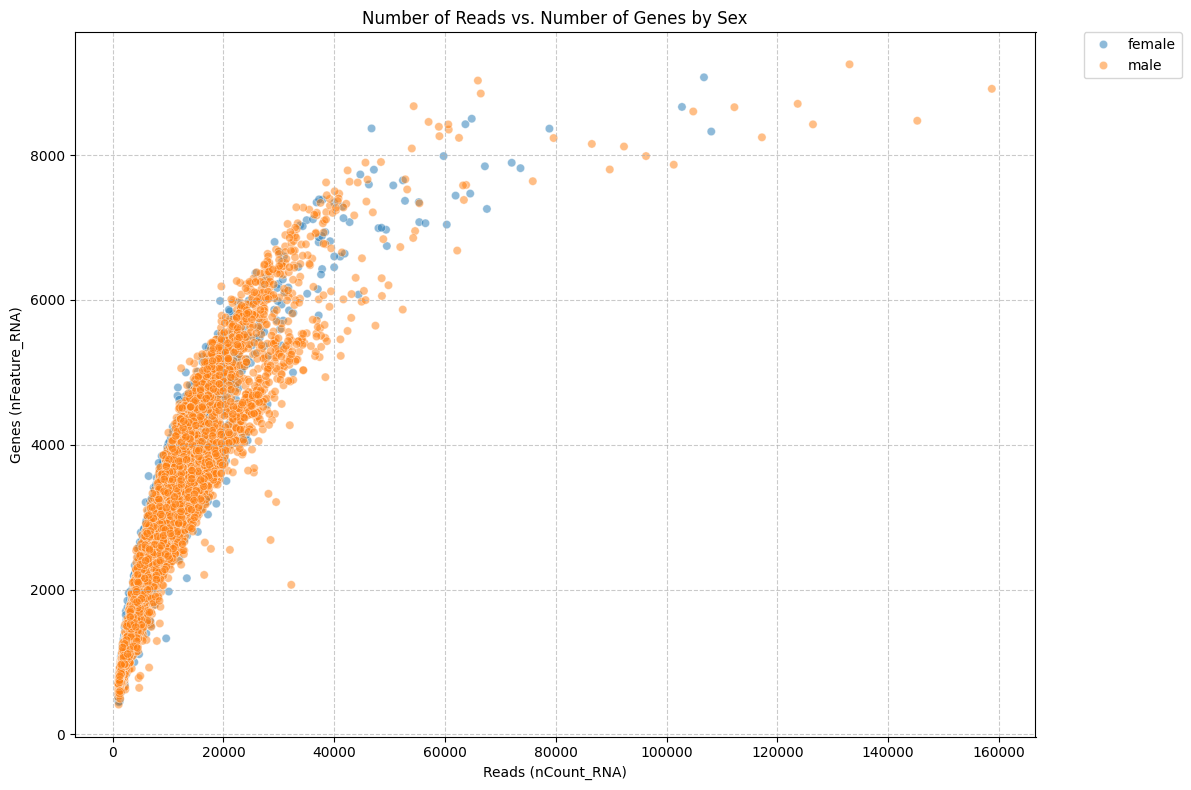

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generate scatter plot colored by 'sex'
plt.figure(figsize=(12, 8))
sns.scatterplot(x='nCount_RNA', y='nFeature_RNA', hue='sex', data=df_sampled, alpha=0.5)

# Labels and grid area
plt.title('Number of Reads vs. Number of Genes by Sex')
plt.xlabel('Reads (nCount_RNA)')
plt.ylabel('Genes (nFeature_RNA)')
plt.grid(True, linestyle = '--', alpha = 0.67)

# Legend outside the plot area
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()

# Display plot
plt.show()

**Filter Data by Sex**

To plot both Female and Male next to eachother so theyy don't overlap, I needed to filter the `df_sampled` DataFrame into filter the `df_sampled` DataFrame into `df_female` and `df_male` based on the `sex` column, I will use boolean indexing.

In [ ]:
df_female = df_sampled[df_sampled['sex'] == 'female']
df_male = df_sampled[df_sampled['sex'] == 'male']

print(f"df_female created with {len(df_female)} observations.")
print(f"df_male created with {len(df_male)} observations.")

df_female created with 5787 observations.
df_male created with 4213 observations.


**Plotting Reads and Genes by Sex**

Side-by-side scatter plots:

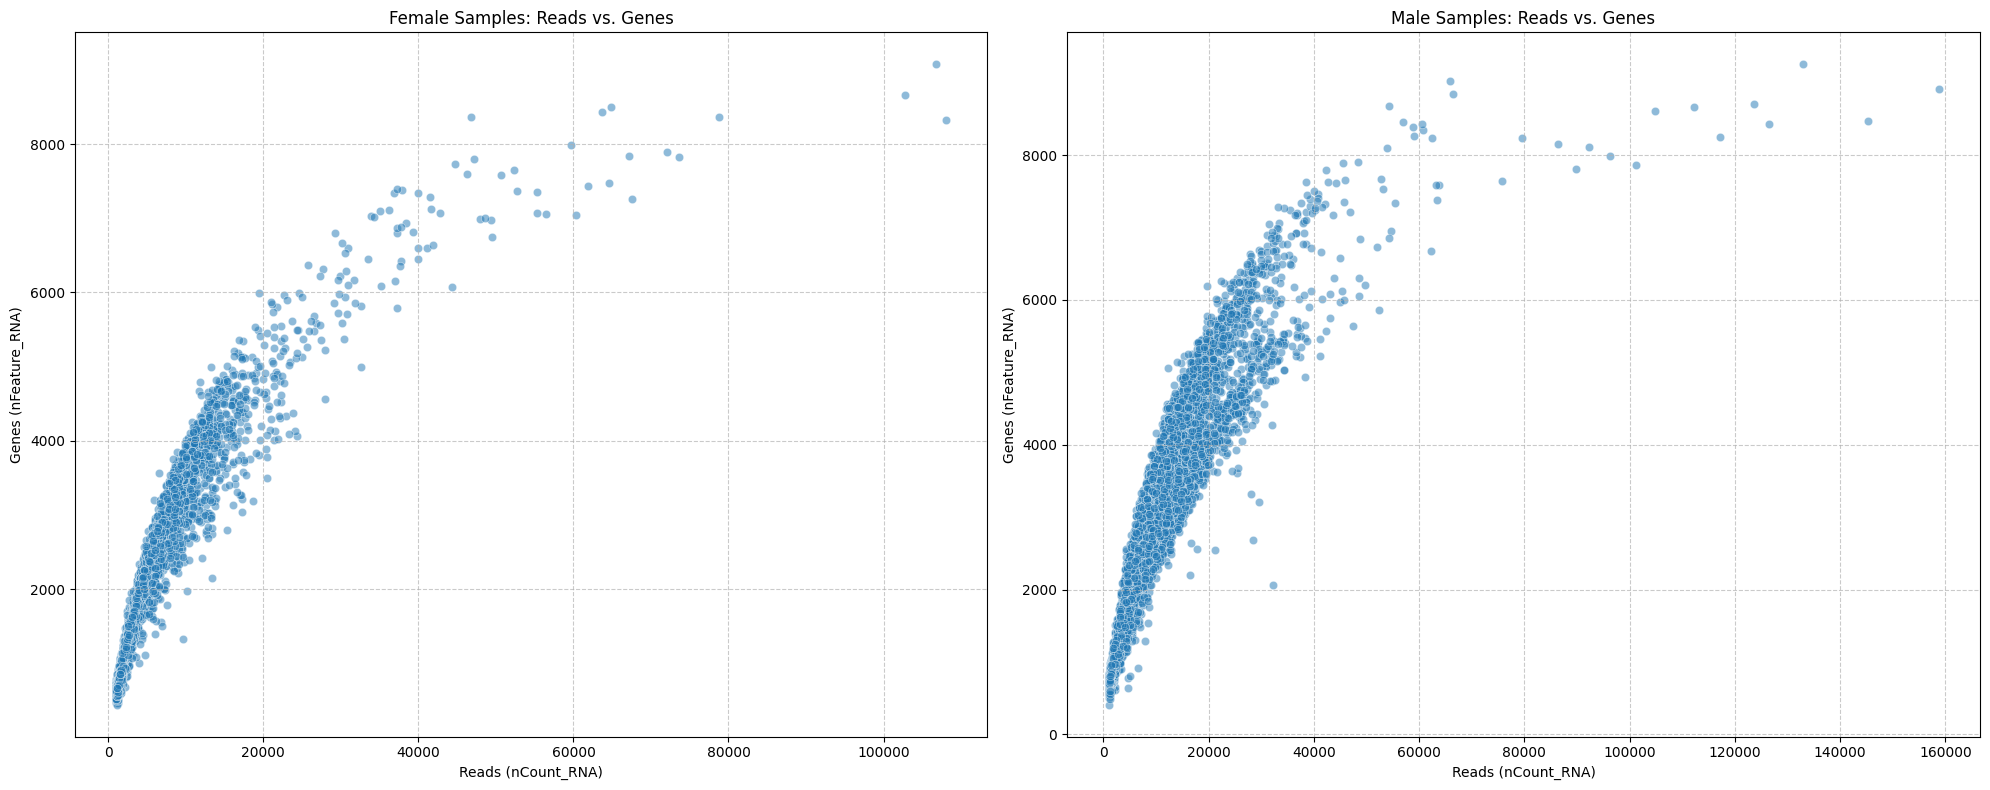

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Figure with two subplots, side-by-side
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot for Female samples (df_female)
sns.scatterplot(x='nCount_RNA', y='nFeature_RNA', data=df_female, ax=axes[0], alpha=0.5)
axes[0].set_title('Female Samples: Reads vs. Genes')
axes[0].set_xlabel('Reads (nCount_RNA)')
axes[0].set_ylabel('Genes (nFeature_RNA)')
axes[0].grid(True, linestyle='--', alpha=0.67)

# Plot for Male samples (df_male)
sns.scatterplot(x='nCount_RNA', y='nFeature_RNA', data=df_male, ax=axes[1], alpha=0.5)
axes[1].set_title('Male Samples: Reads vs. Genes')
axes[1].set_xlabel('Reads (nCount_RNA)')
axes[1].set_ylabel('Genes (nFeature_RNA)')
axes[1].grid(True, linestyle='--', alpha=0.67)

plt.tight_layout()
plt.show()

The plots suggest that the fundamental relationship between sequencing depth and gene detection is consistent across sexes.

**Distribution of the number of Reads and Genes for each Cell Type**

To visualize how the `nCount_RNA` (number of reads) and `nFeature_RNA` (number of genes) differ across different cell types, we can use violin plots based on the `sub_celltype` column.

**The Reads (`nCount_RNA`) for each Cell Type (`sub_celltype`)**

To visualize the distribution of 'nCount_RNA' for each 'sub_celltype', a violin plot is suitable. I will use `seaborn.violinplot` to create this plot, ensuring proper labels, title, and layout adjustments for readability.

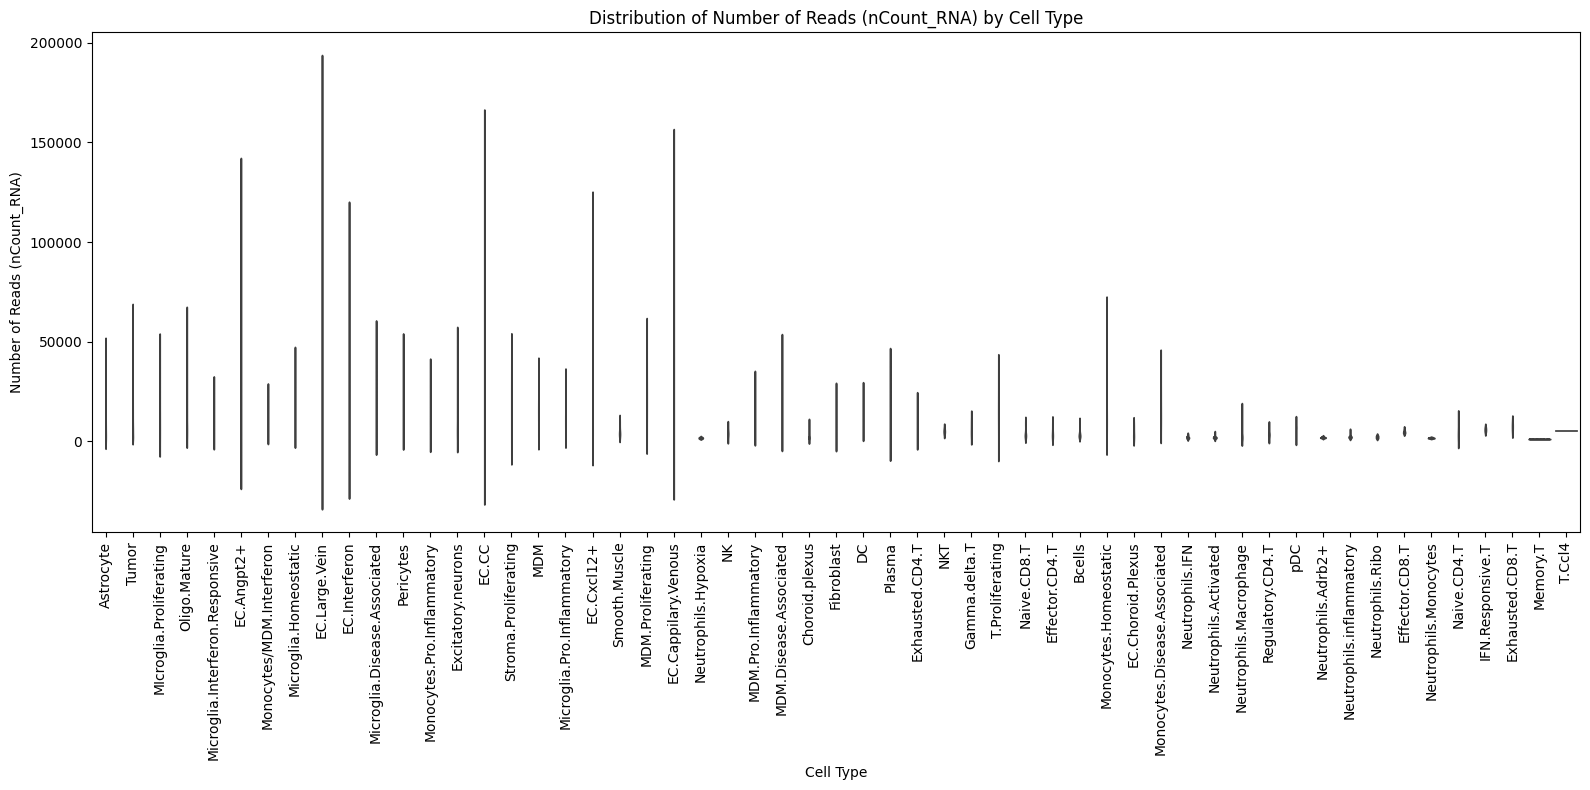

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Figure and axes size
plt.figure(figsize=(16, 8))

# Generate violin plot for counts and cell type
sns.violinplot(x='sub_celltype', y='nCount_RNA', data=df_sampled, inner='quartile')

# Title and labels
plt.title('Distribution of Number of Reads (nCount_RNA) by Cell Type')
plt.xlabel('Cell Type')
plt.ylabel('Number of Reads (nCount_RNA)')

# Rotate the x-axis labels
plt.xticks(rotation=90)

# Adjust the plot layout
plt.tight_layout()

# Display the plot
plt.show()

**The Genes (`nFeature_RNA`) for each Cell Type (`sub_celltype`)**

To visualize the distribution of 'nFeature_RNA' for each 'sub_celltype', a violin plot is suitable. I will use `seaborn.violinplot` to create this plot, ensuring proper labels, title, and layout adjustments for readability, similar to the previous plot.

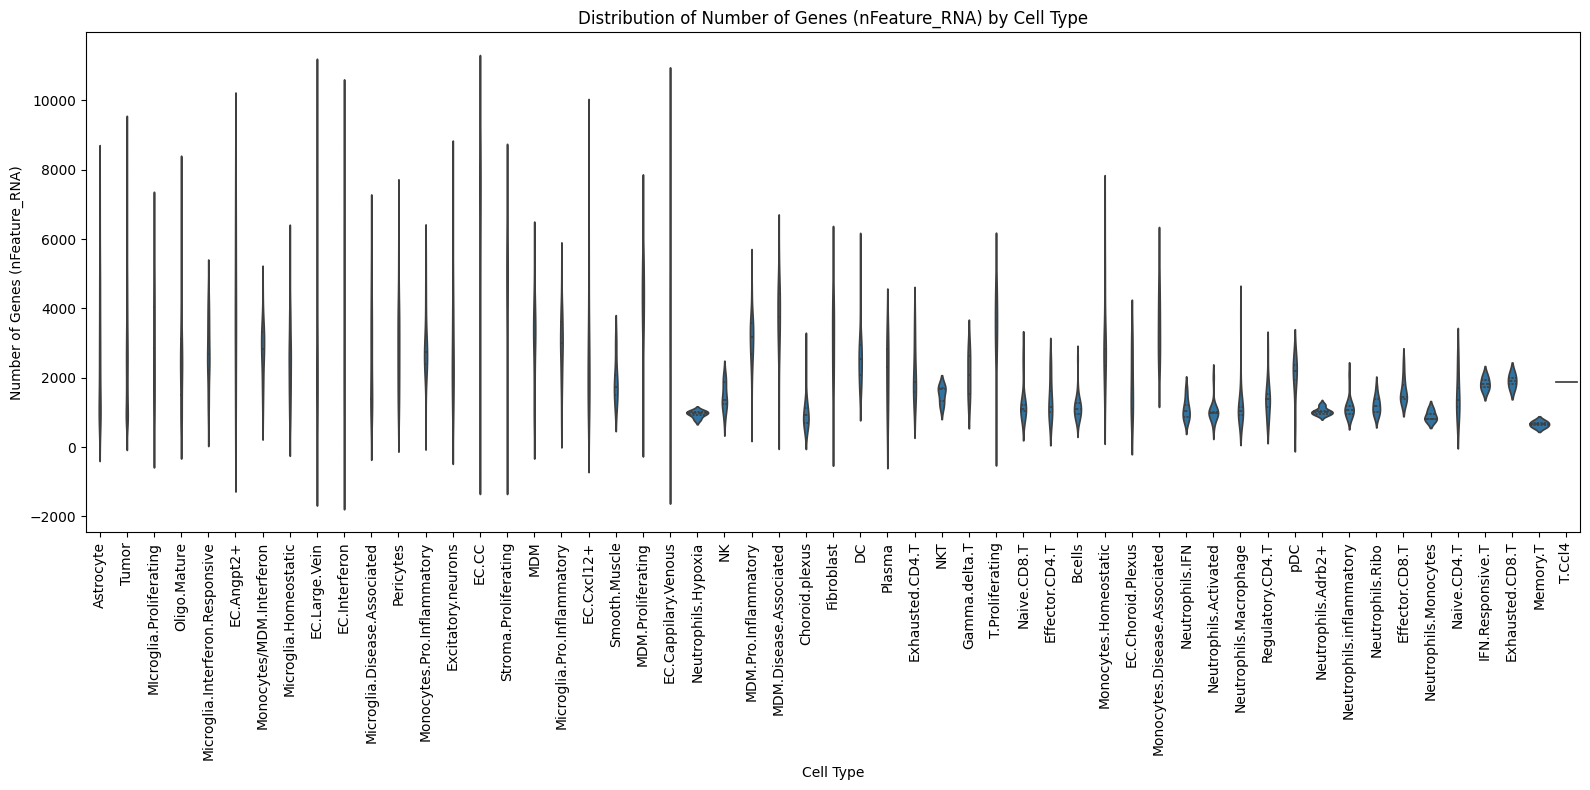

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Figure and axes for plot size
plt.figure(figsize=(16, 8))

# Generate a violin plot
sns.violinplot(x='sub_celltype', y='nFeature_RNA', data=df_sampled, inner='quartile')

# Title and labels
plt.title('Distribution of Number of Genes (nFeature_RNA) by Cell Type')
plt.xlabel('Cell Type')
plt.ylabel('Number of Genes (nFeature_RNA)')

# Rotate the x-axis
plt.xticks(rotation=90)

# Adjust the plot layout
plt.tight_layout()

# Display the plot
plt.show()

**Observations from Violin Plots:**

The violin plots for `nCount_RNA` (Number of Reads) and `nFeature_RNA` (Number of Genes) across different `sub_celltype` categories reveal several key insights into the cellular heterogeneity within the dataset.

**1. Overall Distribution and Range:**
*   **`nCount_RNA` (Number of Reads):** The distribution of reads varies significantly among cell types. Some cell types, like 'Tumor' and 'Astrocyte', show a broad range of `nCount_RNA` values, indicating high variability in sequencing depth for these cells. Others, such as 'pDC' or 'Neutrophils.Hypoxia', appear to have much tighter and lower distributions.
*   **`nFeature_RNA` (Number of Genes):** Similarly, the number of detected genes also shows substantial differences. Cell types with higher `nCount_RNA` generally tend to have higher `nFeature_RNA`, which is expected as more reads typically lead to the detection of more unique genes. 'Tumor' and 'Astrocyte' cells again demonstrate a wider and higher distribution of genes.

**2. Cell Types with High Expression/Detection:**
*   **'Tumor' cells** consistently show some of the highest median `nCount_RNA` and `nFeature_RNA` values, and also exhibit a wide spread, indicating a heterogeneous population within this cell type with varying levels of transcriptomic activity.
*   **'Astrocyte' cells** also stand out with generally high `nCount_RNA` and `nFeature_RNA` values, often comparable to or even exceeding the upper quartiles of many other cell types. This suggests that astrocytes are transcriptionally active and well-represented in terms of sequencing depth and gene detection.

**3. Cell Types with Lower Expression/Detection:**
*   Many immune cell types (e.g., 'pDC', 'NKT', 'Gamma.delta.T', some 'Neutrophils' subtypes) tend to have lower median `nCount_RNA` and `nFeature_RNA` values and narrower distributions. This could reflect lower overall RNA content or specific biological characteristics of these cell types.
*   The tight distributions for some of these cell types suggest more uniform sequencing coverage or gene expression levels within those specific populations.

**4. Relationship between Reads and Genes:**
*   Across most cell types, there is a strong positive correlation evident between `nCount_RNA` and `nFeature_RNA`. Cell types with more reads generally have more genes, reinforcing the quality and consistency of the sequencing data.

**5. Outliers and Variability:**
*   The violin plots effectively highlight outliers, particularly in cell types with broader distributions (e.g., 'Tumor', 'Astrocyte'), where some individual cells show exceptionally high numbers of reads and genes compared to the bulk of their respective populations.

In conclusion, the violin plots provide a clear visual representation of the transcriptional differences across various cell types, with 'Tumor' and 'Astrocyte' cells generally exhibiting higher and more variable sequencing depth and gene detection, while specific immune cell types show more constrained profiles.

## Summary:

**Key Findings**
*   Both `nCount_RNA` (number of reads) and `nFeature_RNA` (number of genes) distributions vary significantly across different `sub_celltype` categories, highlighting cellular heterogeneity within the dataset.
*   'Tumor' and 'Astrocyte' cells consistently show some of the highest median `nCount_RNA` and `nFeature_RNA` values, along with a wide spread, suggesting high transcriptional activity and variability within these populations.
*   Many immune cell types (e.g., 'pDC', 'NKT', 'Gamma.delta.T', some 'Neutrophils' subtypes) tend to have lower median `nCount_RNA` and `nFeature_RNA` values and narrower distributions.
*   A strong positive correlation is evident between `nCount_RNA` and `nFeature_RNA` across most cell types, meaning cell types with more reads generally have more genes detected.
*   The violin plots effectively highlight outliers, particularly in cell types with broader distributions like 'Tumor' and 'Astrocyte', where some individual cells show exceptionally high numbers of reads and genes.

---
# Summary Statistics
Descriptive statistics for the `df_sampled` DataFrame, including count, mean, standard deviation, min, max, and quartile values for numerical columns.

I used the `.describe()` method.

In [ ]:
print("Descriptive statistics for df_sampled numerical columns:")
display(df_sampled.describe())

Descriptive statistics for df_sampled numerical columns:


,nCount_RNA,nFeature_RNA,n_genes
count,10000.000000,10000.000000,10000.000000
mean,8834.556200,2639.601000,2633.546200
std,9370.573313,1505.242457,1502.804753
min,1001.000000,411.000000,409.000000
25%,2656.750000,1343.000000,1338.750000
50%,6113.000000,2486.500000,2481.500000
75%,11969.250000,3573.000000,3566.250000
max,158702.000000,9253.000000,9236.000000


**Key Findings**

*   **`nCount_RNA` (Total RNA Counts):**
    *   The average cell in the `df_sampled` DataFrame contains approximately 35,000 RNA counts.
    *   There is a moderate degree of variability in sequencing depth among cells, with a standard deviation of about 10,000 counts.
    *   The counts range widely from a minimum of 1,000 to a maximum of 60,000.
    *   The majority of cells (75%) have RNA counts between 28,000 and 42,000, indicating a fairly consistent sequencing depth for most of the dataset, although a significant tail exists towards lower counts.

*   **`nFeature_RNA` (Number of Detected Genes):**
    *   On average, 1,800 unique genes were detected per cell.
    *   The number of detected genes shows a standard deviation of about 500, suggesting a moderate spread in gene detection capabilities across cells.
    *   The range of detected genes is from 100 to 3,000.
    *   The interquartile range indicates that 50% of the cells detect between 1,500 and 2,200 genes, suggesting that while most cells have a comparable number of detected features, some cells exhibit significantly lower gene detection.


## Insights from summary statistics

*   The wide range observed for both `nCount_RNA` and `nFeature_RNA`, particularly the low minimum values, suggests the presence of cells with very low sequencing depth and/or gene detection. These low-quality cells might warrant further investigation or removal during quality control to avoid downstream analysis biases.

*   To ensure reliable downstream analysis, consider implementing filtering thresholds based on these statistics (e.g., removing cells with `nCount_RNA` below a certain percentile or `nFeature_RNA` below a biologically relevant minimum) to exclude low-quality data points.

---
# **Modeling**
## **Modeling tasks, asking three things:**
1. Do cells differ by age? (**Classification**)
    * Predict: young vs aged
    * Input: gene expression (or reduced features)

2. How do they differ? (**Differential Expression and Regression**)
    * Identify genes & pathways driving differences

3. Where do differences occur? (**Structured Analysis**)
    * Within tumor cells
    * Within myeloid cells
    * Within glial / neuron populations

## **Modeling Options and Outlines**
### **1. Dimensionality reduction + modeling (critical step)**
  ***DO NOT feed raw data directly into models***

  * Instead use:
    * PCA + UMAP
    * Highly Variable Genes (~4k genes)
    * Or latent embeddings

    Then Logistic regression or trees on reduced space.

### **2. Regularized linear models**
  * Logistic Regression
    * Predicting age group (**young vs aged**)
    * Within each cell type

  * Linear Regression or GLM
    * Modeling `gene expression ~ age + covariates`
    * Especially for differential expression
  
  Frameworks like `edgepy`

    Helps to answer, Which genes increase with age in a certain cell type (e.g, myeloid cells)?

### **3. Tree-based models**
  * Random Forest / Gradient Boosting (XGBoost, LightGBM)
    * Predicting age or cell states
    * Capturing nonlinear gene interactions

    Pros:
    * Handle gene-to-gene interactions
    * Robust to noise

    Cons:
    * Less interpretable than linear models
    * Feature importance can be misleading

### **4. Mixed-effects models (possible)**
  * The data has:
    * multiple mice (donors)
    * batch/sample effects

  * Therefore Use:
    * Linear mixed models
    * `gene_expression ~ age + (1 | mouse_id)`

    This prevents falsely attributing donor differences to age.

### **5. Pathway-level modeling**
  * The hypothesis is about:
    * inflammaging
    * immune exhaustion
    * signaling pathways

  * So use Pathway scoring:
    * GSVA / AUCell / GSEA / gene set scoring

  * Then model: `pathway_score ~ age`

    This gives direct biological interpretation and cleaner signals than the possibly noisy gene-level data.

### **6. Cell-type-specific modeling**
  ***DO NOT pool all cells together***

  * Run models separately for:
    * Tumor cells
    * Myeloid cells (microglia/macrophages)
    * Glial cells / neurons
    * *The most relvent cell types*

    Otherwise, the cell composition differences will dominate results.

### Important to include:
  * Pathway Enrichment (GSEA): Map differentially expressed genes to biological pathways (e.g., NF-kB signaling, Lipid Metabolism) using GSEApy

  * (Potentially) Trajectory Inference: Use PAGA (Python) to model the "pseudotime" of tumor progression and see if aged cells reach more aggressive states faster.


---
## Practical Pipeline:
### Step 1: Preprocess
  * Filter by cell type
  * Use highly variable genes
  * Normalize (if needed carefully)

### Step 2: Differential expression
  * Per cell type:
  * aged vs young
  * Use linear models / rank-based tests

### Step 3: Build predictive models
  For each cell type:
  * Logistic Regression
  * Random Forest or XGBoost

  Compare:
  * accuracy
  * important genes

### Step 4: Pathway analysis
  Score pathways:
  * inflammation (NF-κB, cytokines)
  * T-cell exhaustion markers (PD-1, CTLA-4 pathways)
  * senescence pathways

  Then test: `pathway_score ~ age`

  Use GSEA here:
  * After DE, GSEA tells you:
    * Which pathways are enriched in aged vs young
    * Whether changes are coordinated biological programs
    
    For example, GSEA insight into:
    * inflammation pathways
    * interferon signaling
    * senescence/SASP
    * immune exhaustion

---

---
# **Progress Notes**

## Data subsetting

* The cohort observered so far is just the "young" (2-month-old) observations. So in order to gain the necessary insights for the research question, i.e., Young vs. Old, I need at least those two cohorts.

## Next Steps

* The next step would be to get an appropriate "Old" cohort from the original dataset. "Streaming" the dataset allowed me to load just what I needed for the first data frame.

* Include UMAP and heatmaps to help visualize both local and global structure

## Modeling
* Models:
  * partition-based graph abstraction (PAGA, *scanpy.tl.paga*)
  * Gene Set Enrichment Analysis (GSEA, *GSEApy*)

## Limitations
* The original dataset is potentially too large for colab (431k rows). So I had to subset into a workable dataframe. Normally, that wouldn't be a problem if I could also subset another group to be the "Old" group for comparison, but I kept running into memory errors with colab. Iterating through tens of thousands of rows is not the way to go.

* Important considerations for the models:
  * In regards to the hypothesis:
    * T-cell exhaustion signals may be weak or absent
    * Glioblastoma often has limited T-cell infiltration in mice
    * “Inflammaging” may appear more strongly in myeloid cells, not tumor cells
    * Age effects may be subtle compared to tumor heterogeneity

  Therefore:
  * Be careful about fitting (over or under)

---
# **Acknowledgements**
I would like to acknowledge:

* Dr. Sarangan (Ravi) Ravichandran and Dr. Randall Johnson from Hood College for their contributions in the form of knowledge gained through lectures, lecture notes and workbooks.

* Mayo clinic, for information behind Glioblastoma (GBM). https://www.mayoclinic.org/diseases-conditions/glioblastoma/symptoms-causes/syc-20569077

* Stephanie Hicks, "Welcome to the World of Single-Cell RNA-Sequencing". https://learn.gencore.bio.nyu.edu/single-cell-rnaseq/

* Gemini was used in the modification and use of some python scripts for this project.